### **Project Objective**

The primary objective of this project is to understand and apply **sentiment analysis techniques** on real-world social media data. By using comments from an Instagram post, the goal is to analyze user opinions and classify them into **positive, negative, and neutral sentiments**.

This project also aims to:

* Gain hands-on experience with **data extraction from social media platforms**
* Perform **data cleaning and preprocessing** on unstructured text data
* Apply **Natural Language Processing (NLP)** techniques for sentiment classification
* Derive meaningful insights about **audience engagement and perception**

---

### **Methodology**

The project was carried out in the following steps:

**1. Data Collection**
Comments were collected from a personal Instagram post with over ~2000 comments. Initially, a Chrome extension (*IG Comments Exporter*) was used, but due to its limitation of extracting only ~200 comments, an alternative approach was adopted.
Using the browser’s **developer console** and JavaScript, comments were successfully extracted directly from the webpage.

**2. Data Preparation**
The extracted data was saved and processed into a structured format (Excel).
Unnecessary elements such as duplicates, system-generated text (e.g., “reply”, “likes”), and noise were removed to obtain a clean dataset of **691 comments**.

**3. Data Processing**
The cleaned dataset was imported into Python using libraries like **pandas**.
Basic preprocessing steps such as trimming text and handling missing values were performed.

**4. Sentiment Analysis**
Sentiment analysis was applied using NLP techniques (TextBlob), where each comment was assigned a **sentiment score** and classified into:

* Positive
* Negative
* Neutral

**5. Data Visualization**
The results were visualized using graphs (bar chart and pie chart) to understand the distribution of sentiments across all comments.

**6. Insight Generation**
Based on the analysis, it was observed that most comments were neutral, while positive comments were significantly higher than negative ones. This indicates that the audience perception of the content is generally favorable.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
file_path = "/Users/nitesh/Downloads/comments.txt"

In [4]:
with open(file_path, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

print(lines[:10])      

['13 yrs old boy SAVED his FAMILY', 'A funny and unexpected video is going viral online, where a man is seen flexing money while vibing to the song “Paisa Paisa.” As he shows off his cash confidently, a little boy suddenly enters the frame and grabs attention. In a surprising twist, the child tears a real ₹500 note, leaving the man shocked and viewers amused. The moment quickly turns from a flex to a hilarious situation, catching everyone off guard. Social media users are loving the unexpected turn, with many calling it the “ultimate reality check.” The clip is widely shared, spreading laughter across the internet.', 'f45_training_townsquare', 'Nothing beats the Saturday hybrid energy — the vibe, the sweat, and the team pushing each other past limits 💪🏽 It’s not just a workout, it’s a movement built on discipline and drive. Weekends are where athletes are made. #HybridAthlete #FunctionalStrength #TeamEnergy', 'พรุ่งนี้ไม่เล่นด้วยแล้วนิ่งเกิน🤣', 'Tame Impala · Dracula', 'Tame Impala · D

In [5]:
comments = []

for line in lines:
    if (
        len(line) > 10 and
        "likes" not in line.lower() and
        "reply" not in line.lower() and
        "view all" not in line.lower() and
        "follow" not in line.lower()
    ):
        comments.append(line)

In [6]:
df = pd.DataFrame(comments, columns=["comment"])

In [7]:
df = df.drop_duplicates()
df = df[df["comment"].str.len() > 10]

print("Total clean comments:", len(df))

Total clean comments: 691


In [8]:
df = pd.read_excel("/Users/nitesh/Downloads/clean_comments.xlsx")
print(df.head())

                                             comment
0                    13 yrs old boy SAVED his FAMILY
1  A funny and unexpected video is going viral on...
2                            f45_training_townsquare
3  Nothing beats the Saturday hybrid energy — the...
4                   พรุ่งนี้ไม่เล่นด้วยแล้วนิ่งเกิน🤣


In [35]:
#pip install textblob

In [9]:
from textblob import TextBlob

df["sentiment_score"] = df["comment"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [10]:
def label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(label)

In [11]:
print(df.head())

                                             comment  sentiment_score  \
0                    13 yrs old boy SAVED his FAMILY         0.100000   
1  A funny and unexpected video is going viral on...         0.183073   
2                            f45_training_townsquare         0.000000   
3  Nothing beats the Saturday hybrid energy — the...        -0.187500   
4                   พรุ่งนี้ไม่เล่นด้วยแล้วนิ่งเกิน🤣         0.000000   

  sentiment  
0  Positive  
1  Positive  
2   Neutral  
3  Negative  
4   Neutral  


In [29]:
print(df["sentiment"].value_counts())

sentiment
Neutral     519
Positive    117
Negative     55
Name: count, dtype: int64


In [13]:
percent = df["sentiment"].value_counts(normalize=True) * 100
print(percent)

sentiment
Neutral     75.108538
Positive    16.931983
Negative     7.959479
Name: proportion, dtype: float64


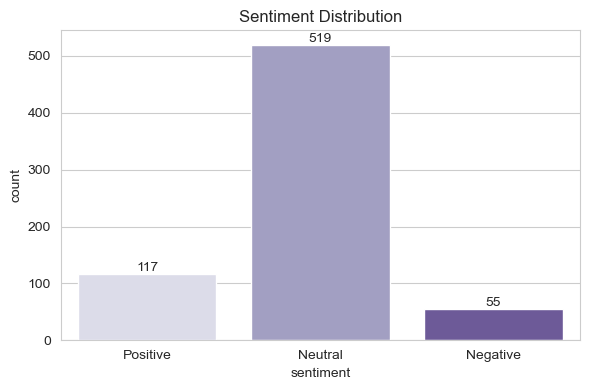

In [26]:
sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

ax = sns.countplot(x="sentiment", data=df, palette="Purples")

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()

#### Displays the distribution of sentiments across all comments.

In [ ]:
super-cali-fragilistic-expia-lidocious

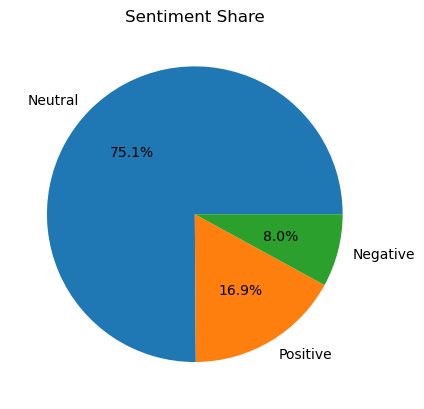

In [16]:
df["sentiment"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Sentiment Share")
plt.ylabel("")
plt.show()

### **Conclusion**

This project highlights the practical application of sentiment analysis on real-world social media data. It demonstrates how user-generated content can be analyzed to understand audience behavior, engagement patterns, and overall sentiment toward digital content.
